# Corrected Earth–Moon transfer (2D demonstration)

This revises the supplied *Lunar Ascent* notebook while keeping its planar, circular-Moon, Earth-centered model. The spacecraft begins in a **200 km Earth parking orbit**. An instantaneous tangential translunar injection (TLI) sends it on a gravitational coast toward the **moving** Moon. We tune the Moon's initial phase so the closest approach is 100 km above the lunar surface, then apply an idealized lunar orbit insertion (LOI) impulse.

This is a **transfer demonstration**, not a launch or fuel-optimal trajectory. Impulsive burns, a fixed Earth/Moon orbit, and no atmosphere or spacecraft mass evolution remain simplifying assumptions. The notebook does not claim a Falcon 9 can perform these burns. All calculations use SI units; plots use km.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

# Original project constants, corrected where the original had wrong units/values.
G = 6.67430e-11
Me, Mm = 5.97219e24, 7.34767309e22
Re, Rm = 6.3781e6, 1.738e6
Lm = 3.844e8
P = 27.321661 * 86400  # sidereal lunar orbital period, seconds
mu_e, mu_m = G * Me, G * Mm
omega_m = 2 * np.pi / P
parking_altitude = 200e3
arrival_altitude = 100e3
r_park = Re + parking_altitude
r_target = Rm + arrival_altitude


## Equations and transfer setup

The Moon moves at every integration time, $\mathbf r_M(t)=L_m(\cos(\phi+\omega_M t),\sin(\phi+\omega_M t))$. In an Earth-centered frame the spacecraft acceleration is

$$\ddot{\mathbf r}=-\mu_E\frac{\mathbf r}{|\mathbf r|^3}+\mu_M\left[\frac{\mathbf r_M-\mathbf r}{|\mathbf r_M-\mathbf r|^3}-\frac{\mathbf r_M}{|\mathbf r_M|^3}\right].$$

The final term is the small indirect correction caused by the Moon's acceleration of the Earth. A two-body transfer ellipse provides the initial TLI speed. The phase search targets **closest approach**, not a straight line or a fixed final Cartesian point.

In [2]:
def moon_position(t, phase):
    angle = phase + omega_m * t
    return Lm * np.array([np.cos(angle), np.sin(angle)])


def moon_velocity(t, phase):
    m = moon_position(t, phase)
    return omega_m * np.array([-m[1], m[0]])


def update(t, state, phase):
    r, v = state[:2], state[2:]
    m = moon_position(t, phase)
    delta = m - r
    a = (-mu_e * r / np.linalg.norm(r)**3
         + mu_m * (delta / np.linalg.norm(delta)**3 - m / np.linalg.norm(m)**3))
    return np.r_[v, a]

# Tangential TLI from the circular parking orbit; this is an impulse model.
v_parking = np.sqrt(mu_e / r_park)
a_transfer = (r_park + Lm) / 2
v_tli = np.sqrt(mu_e * (2 / r_park - 1 / a_transfer))
delta_v_tli = v_tli - v_parking
initial_state = np.array([r_park, 0, 0, v_tli])
print(f'Parking-orbit speed: {v_parking/1000:.3f} km/s')
print(f'TLI impulse: {delta_v_tli/1000:.3f} km/s')


Parking-orbit speed: 7.784 km/s
TLI impulse: 3.131 km/s


In [3]:
def closest_approach(phase):
    def radial_rate(t, state, _phase):
        relative_r = state[:2] - moon_position(t, phase)
        relative_v = state[2:] - moon_velocity(t, phase)
        return np.dot(relative_r, relative_v)
    radial_rate.direction = 1  # inbound to outbound
    radial_rate.terminal = False
    solution = solve_ivp(update, (0, 7*86400), initial_state, args=(phase,),
                         events=radial_rate, rtol=1e-9, atol=1e-5,
                         max_step=900, dense_output=True)
    if not solution.success:
        raise RuntimeError(solution.message)
    encounters = [(np.linalg.norm(state[:2] - moon_position(t, phase)), t, state)
                  for t, state in zip(solution.t_events[0], solution.y_events[0])
                  if t > 2*86400]
    if not encounters:
        raise RuntimeError('No lunar encounter after day 2')
    distance, time, state = min(encounters, key=lambda item: item[0])
    return distance, time, state, solution

# Choose a safe, 100 km perilune rather than an impact trajectory.
phase = brentq(lambda phi: closest_approach(phi)[0] - r_target,
               1.80, 1.90, xtol=1e-10)
perilune_radius, t_perilune, preburn, transfer = closest_approach(phase)
assert abs(perilune_radius - r_target) < 1e3
assert np.min(np.linalg.norm(transfer.y[:2], axis=0)) > Re
print(f'Moon initial phase: {np.degrees(phase):.3f}°')
print(f'Perilune: day {t_perilune/86400:.3f}, altitude {(perilune_radius-Rm)/1000:.2f} km')


Moon initial phase: 108.418°
Perilune: day 5.289, altitude 100.00 km


## Lunar orbit insertion

At perilune, set the Moon-relative velocity tangent to the radius with magnitude $\sqrt{\mu_M/r_p}$. The difference is the idealized LOI impulse. This is a simplified circular-orbit target; Earth perturbations remain in the subsequent integration.

In [4]:
moon_at_arrival = moon_position(t_perilune, phase)
moon_v_at_arrival = moon_velocity(t_perilune, phase)
relative_r = preburn[:2] - moon_at_arrival
relative_v = preburn[2:] - moon_v_at_arrival
radial_speed = np.dot(relative_r, relative_v) / perilune_radius
sense = np.sign(relative_r[0]*relative_v[1] - relative_r[1]*relative_v[0])
tangent = sense * np.array([-relative_r[1], relative_r[0]]) / perilune_radius
v_circular = np.sqrt(mu_m / perilune_radius)
postburn = preburn.copy()
postburn[2:] = moon_v_at_arrival + v_circular * tangent
delta_v_loi = np.linalg.norm(postburn[2:] - preburn[2:])

orbit_period = 2*np.pi*np.sqrt(perilune_radius**3/mu_m)
post = solve_ivp(update, (t_perilune, t_perilune + 2*orbit_period),
                 postburn, args=(phase,), rtol=1e-10, atol=1e-6,
                 max_step=60, dense_output=True)
assert post.success, post.message
post_times = np.linspace(t_perilune, t_perilune + 2*orbit_period, 1000)
post_states = post.sol(post_times)
moon_after = np.array([moon_position(t, phase) for t in post_times]).T
altitudes = np.linalg.norm(post_states[:2] - moon_after, axis=0) - Rm
assert np.min(altitudes) > 0, 'Post-LOI trajectory intersects the Moon'
print(f'Arrival speed relative to Moon: {np.linalg.norm(relative_v)/1000:.3f} km/s')
print(f'Radial speed at perilune: {radial_speed:.4f} m/s')
print(f'Idealized LOI impulse: {delta_v_loi/1000:.3f} km/s')
print(f'Post-LOI altitude over two orbits: {altitudes.min()/1000:.1f}–{altitudes.max()/1000:.1f} km')


Arrival speed relative to Moon: 2.451 km/s
Radial speed at perilune: 0.0000 m/s
Idealized LOI impulse: 0.818 km/s
Post-LOI altitude over two orbits: 99.9–100.1 km


## Results

The first plot uses an Earth-centered inertial frame; the Moon moves along the dashed arc. The second plot is Moon-centered, showing the approach and two post-insertion revolutions. The target and plotted trajectory come from the integrated state, not from a line drawn between endpoints.

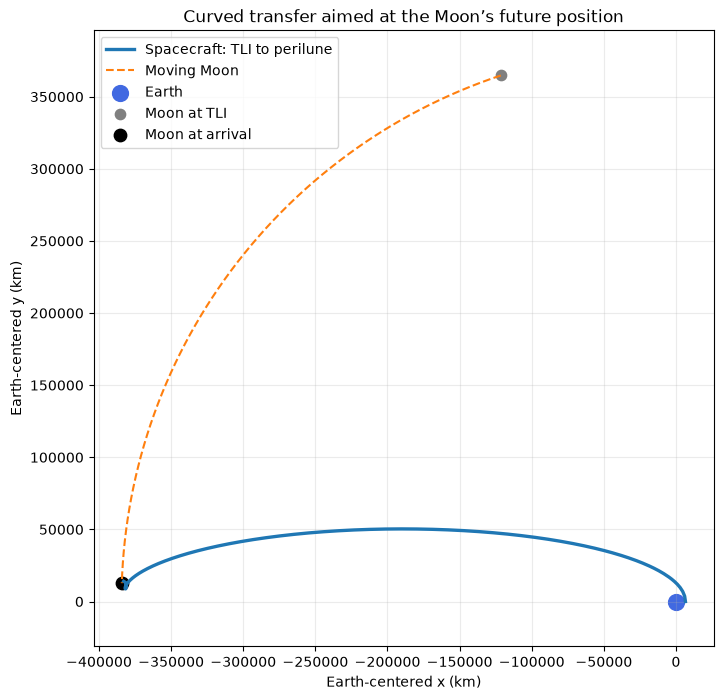

In [5]:
times = np.linspace(0, t_perilune, 1300)
states = transfer.sol(times)
moons = np.array([moon_position(t, phase) for t in times]).T

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(states[0]/1000, states[1]/1000, lw=2.4, label='Spacecraft: TLI to perilune')
ax.plot(moons[0]/1000, moons[1]/1000, '--', lw=1.5, label='Moving Moon')
ax.scatter([0], [0], s=130, color='royalblue', label='Earth')
ax.scatter([moons[0,0]/1000], [moons[1,0]/1000], s=55, color='gray', label='Moon at TLI')
ax.scatter([moon_at_arrival[0]/1000], [moon_at_arrival[1]/1000], s=80, color='black', label='Moon at arrival')
ax.set(xlabel='Earth-centered x (km)', ylabel='Earth-centered y (km)',
       title='Curved transfer aimed at the Moon’s future position')
ax.axis('equal'); ax.grid(alpha=.25); ax.legend(loc='best')
plt.show()


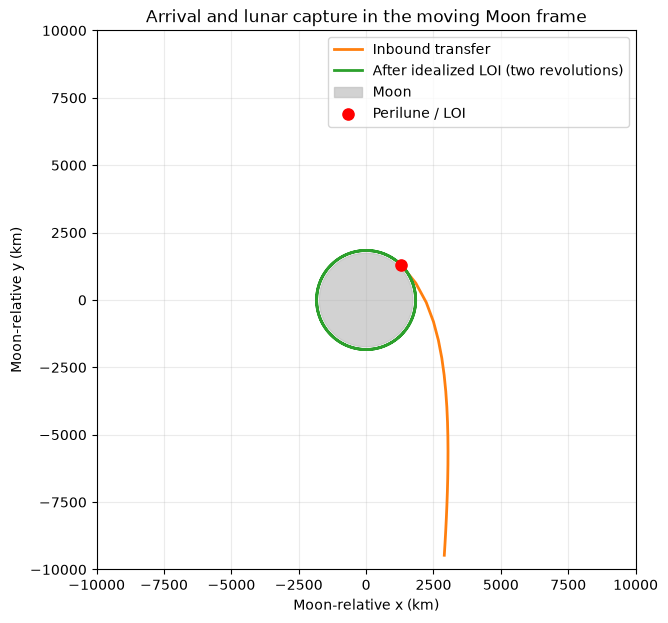

In [6]:
relative_transfer = states[:2] - moons
relative_orbit = post_states[:2] - moon_after
fig, ax = plt.subplots(figsize=(8, 7))
near_moon = np.linalg.norm(relative_transfer, axis=0) < 10000e3
ax.plot(relative_transfer[0,near_moon]/1000, relative_transfer[1,near_moon]/1000,
        color='tab:orange', lw=2, label='Inbound transfer')
ax.plot(relative_orbit[0]/1000, relative_orbit[1]/1000,
        color='tab:green', lw=2, label='After idealized LOI (two revolutions)')
ax.add_patch(plt.Circle((0,0), Rm/1000, color='silver', alpha=.7, label='Moon'))
ax.scatter([relative_r[0]/1000], [relative_r[1]/1000], color='red', s=65, zorder=5,
           label='Perilune / LOI')
ax.set(xlabel='Moon-relative x (km)', ylabel='Moon-relative y (km)',
       title='Arrival and lunar capture in the moving Moon frame')
ax.set_xlim(-10000,10000); ax.set_ylim(-10000,10000)
ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=.25); ax.legend(loc='upper right')
plt.show()


### What this does and does not establish

The integration demonstrates a curved, Moon-phased transfer and an idealized insertion into a short-lived lunar orbit. It verifies an above-surface perilune and two collision-free post-burn revolutions. It does **not** model launch through the atmosphere, finite-duration burns, propellant use, staging, spacecraft feasibility, or an optimal-control solution. Those claims from the original poster should not be retained.